# 08 - Ensemble dos 3 Modelos


In [1]:
import os
import sys
import pickle
import random
import json

sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader

from src.data_processing import clean_text, clean_text_sequences
from src.features import TextDataset, Vocabulary, load_glove_embeddings, texts_to_sequences
from src.models_numpy.dnn import CategoricalCrossEntropy, Dataset, NeuralNetwork, accuracy
from src.models_pytorch.cnn1d import CNN1DClassifier
from src.models_pytorch.distilbert import DistilBERTClassifier, DistilBERTDataset, get_tokenizer


In [2]:
ROOT = os.path.abspath('..')
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
EXEMPLOS_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
EARLY_STOP_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')
EVAL_PATH = os.path.join(ROOT, 'data', 'validation', 'subm2_labels_revealed.csv')
GLOVE_PATH = os.path.join(ROOT, 'data', 'embeddings', 'glove.6B.100d.txt')
SAVED_MODELS_DIR = os.path.join(ROOT, 'saved_models')

DNN_CFG = {'max_words': 2000}
CNN_CFG = {'vocab_size': 1000, 'embedding_dim': 100, 'n_filters': 64, 'filter_sizes': [2, 3], 'dropout': 0.2, 'batch_size': 32, 'max_len': 200}
BERT_CFG = {'dropout': 0.1, 'batch_size': 8, 'max_len': 128}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
  GPU: AMD Radeon Graphics


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


## 1. Load Data


In [3]:
def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    return df


def evaluate_probs(probs, labels, name):
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}')
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))
    print(pd.DataFrame(confusion_matrix(labels, preds), index=CLASSES, columns=CLASSES))
    return acc, macro_f1


def soft_voting(probabilities, weights=None):
    if weights is None:
        weights = [1.0 / len(probabilities)] * len(probabilities)
    return sum(weight * probs for weight, probs in zip(weights, probabilities))


df_train = load_data(TRAIN_PATH)
df_exemplos = load_data(EXEMPLOS_PATH)
df_full = pd.concat([df_train, df_exemplos], ignore_index=True)
df_es = load_data(EARLY_STOP_PATH)
df_eval = load_data(EVAL_PATH)

print(f'Train final: {len(df_full)} (combined={len(df_train)} + exemplos={len(df_exemplos)})')
print(f'Early stop (subm1): {len(df_es)}')
print(f'Eval (subm2): {len(df_eval)}')


Train final: 4740 (combined=4615 + exemplos=125)
Early stop (subm1): 100
Eval (subm2): 100


## 2. Load DNN Weights


In [4]:
dnn_model = NeuralNetwork(loss=CategoricalCrossEntropy, metric=accuracy, verbose=False)
dnn_model.load(os.path.join(SAVED_MODELS_DIR, 'dnn_final_model.npz'))

with open(os.path.join(SAVED_MODELS_DIR, 'dnn_final_vectorizer.pkl'), 'rb') as f:
    dnn_vectorizer = pickle.load(f)


def predict_dnn(model, vectorizer, texts_raw):
    texts_clean = [clean_text(text) for text in texts_raw]
    X = vectorizer.transform(texts_clean, texts_raw)
    return model.predict(Dataset(X, np.zeros((len(texts_raw), NUM_CLASSES))))


dnn_es = predict_dnn(dnn_model, dnn_vectorizer, df_es['Text'].tolist())
dnn_eval = predict_dnn(dnn_model, dnn_vectorizer, df_eval['Text'].tolist())


## 3. Load CNN1D Weights


In [5]:
cnn_vocab = Vocabulary(max_words=CNN_CFG['vocab_size'])
cnn_vocab.load(os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_vocab.pkl'))

with open(os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_config.json'), 'r') as f:
    cnn_cfg = json.load(f)

style_stats = np.load(os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_style_stats.npz'))
style_mean = style_stats['mean']
style_std = style_stats['std']

with open(os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_style_extractor.pkl'), 'rb') as f:
    cnn_style_extractor = pickle.load(f)

cnn_embeddings = None
if os.path.exists(GLOVE_PATH):
    cnn_embeddings = load_glove_embeddings(GLOVE_PATH, cnn_vocab, embedding_dim=cnn_cfg['embedding_dim'])

cnn_model = CNN1DClassifier(
    vocab_size=len(cnn_vocab),
    embedding_dim=cnn_cfg['embedding_dim'],
    n_filters=cnn_cfg['n_filters'],
    filter_sizes=cnn_cfg['filter_sizes'],
    output_dim=NUM_CLASSES,
    dropout=cnn_cfg['dropout'],
    pretrained_embeddings=cnn_embeddings,
    n_style_features=len(style_mean),
).to(DEVICE)

cnn_model.load_state_dict(torch.load(os.path.join(SAVED_MODELS_DIR, 'cnn1d_final_model.pt'), map_location=DEVICE))
cnn_model.eval()


def predict_cnn(model, vocab, style_extractor, style_mean, style_std, texts_raw):
    texts_clean = [clean_text_sequences(text) for text in texts_raw]
    sequences = texts_to_sequences(texts_clean, vocab, max_len=cnn_cfg['max_len'])
    style = style_extractor.transform(texts_raw)
    style = (style - style_mean) / style_std
    dataset = TextDataset(sequences, np.zeros(len(texts_raw), dtype=np.int64), style)
    loader = DataLoader(dataset, batch_size=CNN_CFG['batch_size'])
    probs = []
    with torch.no_grad():
        for seqs, style_batch, _ in loader:
            seqs = seqs.to(DEVICE)
            style_batch = style_batch.to(DEVICE)
            probs.append(torch.softmax(model(seqs, style_batch), dim=1).cpu().numpy())
    return np.vstack(probs)


cnn_es = predict_cnn(cnn_model, cnn_vocab, cnn_style_extractor, style_mean, style_std, df_es['Text'].tolist())
cnn_eval = predict_cnn(cnn_model, cnn_vocab, cnn_style_extractor, style_mean, style_std, df_eval['Text'].tolist())


GloVe: 1000/1002 palavras encontradas (99.8%)


## 4. Load DistilBERT Weights


In [6]:
bert_tokenizer = get_tokenizer()
bert_model = DistilBERTClassifier(output_dim=NUM_CLASSES, dropout=BERT_CFG['dropout'], freeze_bert=False).to(DEVICE)
bert_model.load_state_dict(torch.load(os.path.join(SAVED_MODELS_DIR, 'distilbert_final_model.pt'), map_location=DEVICE))
bert_model.eval()


def predict_bert(model, texts, labels):
    dataset = DistilBERTDataset(texts, labels, bert_tokenizer, max_len=BERT_CFG['max_len'])
    loader = DataLoader(dataset, batch_size=BERT_CFG['batch_size'])
    probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            logits = model(input_ids, attention_mask)
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(probs)


bert_es = predict_bert(bert_model, df_es['Text'].tolist(), df_es['label_id'].values)
bert_eval = predict_bert(bert_model, df_eval['Text'].tolist(), df_eval['label_id'].values)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/.venv/lib/python3.14/site-packages/transformers/integrations/sdpa_attention.py:92: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:338.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
/home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/.venv/lib/python3.14/s

## 5. Individual Results


In [7]:
results = []

dnn_es_acc, dnn_es_f1 = evaluate_probs(dnn_es, df_es['label_id'].values, 'DNN - ES (subm1)')
dnn_eval_acc, dnn_eval_f1 = evaluate_probs(dnn_eval, df_eval['label_id'].values, 'DNN - Eval (subm2)')
results.append({'Model': 'DNN (Forensic)', 'ES_Acc': dnn_es_acc, 'ES_F1': dnn_es_f1, 'Eval_Acc': dnn_eval_acc, 'Eval_F1': dnn_eval_f1})

cnn_es_acc, cnn_es_f1 = evaluate_probs(cnn_es, df_es['label_id'].values, 'CNN1D - ES (subm1)')
cnn_eval_acc, cnn_eval_f1 = evaluate_probs(cnn_eval, df_eval['label_id'].values, 'CNN1D - Eval (subm2)')
results.append({'Model': 'CNN1D (GloVe+Style)', 'ES_Acc': cnn_es_acc, 'ES_F1': cnn_es_f1, 'Eval_Acc': cnn_eval_acc, 'Eval_F1': cnn_eval_f1})

bert_es_acc, bert_es_f1 = evaluate_probs(bert_es, df_es['label_id'].values, 'DistilBERT - ES (subm1)')
bert_eval_acc, bert_eval_f1 = evaluate_probs(bert_eval, df_eval['label_id'].values, 'DistilBERT - Eval (subm2)')
results.append({'Model': 'DistilBERT', 'ES_Acc': bert_es_acc, 'ES_F1': bert_es_f1, 'Eval_Acc': bert_eval_acc, 'Eval_F1': bert_eval_f1})



=== DNN - ES (subm1) ===
Accuracy: 0.6800 | Macro F1: 0.6458
              precision    recall  f1-score   support

   Anthropic       0.83      0.59      0.69        17
      Google       0.55      0.65      0.59        17
       Human       0.84      0.76      0.80        34
        Meta       0.73      0.89      0.80        18
      OpenAI       0.33      0.36      0.34        14

    accuracy                           0.68       100
   macro avg       0.66      0.65      0.65       100
weighted avg       0.70      0.68      0.68       100

           Anthropic  Google  Human  Meta  OpenAI
Anthropic         10       3      1     0       3
Google             1      11      1     0       4
Human              0       1     26     6       1
Meta               0       0      0    16       2
OpenAI             1       5      3     0       5

=== DNN - Eval (subm2) ===
Accuracy: 0.7200 | Macro F1: 0.7108
              precision    recall  f1-score   support

   Anthropic       0.60      0

## 6. Ensemble: Soft Voting


In [8]:
soft_equal_es = soft_voting([dnn_es, cnn_es, bert_es])
soft_equal_eval = soft_voting([dnn_eval, cnn_eval, bert_eval])
se_es_acc, se_es_f1 = evaluate_probs(soft_equal_es, df_es['label_id'].values, 'Soft Vote (equal) - ES')
se_eval_acc, se_eval_f1 = evaluate_probs(soft_equal_eval, df_eval['label_id'].values, 'Soft Vote (equal) - Eval')
results.append({'Model': 'SoftVote (equal)', 'ES_Acc': se_es_acc, 'ES_F1': se_es_f1, 'Eval_Acc': se_eval_acc, 'Eval_F1': se_eval_f1})

soft_bal_es = soft_voting([dnn_es, cnn_es, bert_es], weights=[0.25, 0.25, 0.50])
soft_bal_eval = soft_voting([dnn_eval, cnn_eval, bert_eval], weights=[0.25, 0.25, 0.50])
sb2_es_acc, sb2_es_f1 = evaluate_probs(soft_bal_es, df_es['label_id'].values, 'Soft Vote (0.25/0.25/0.50) - ES')
sb2_eval_acc, sb2_eval_f1 = evaluate_probs(soft_bal_eval, df_eval['label_id'].values, 'Soft Vote (0.25/0.25/0.50) - Eval')
results.append({'Model': 'SoftVote (0.25/0.25/0.50)', 'ES_Acc': sb2_es_acc, 'ES_F1': sb2_es_f1, 'Eval_Acc': sb2_eval_acc, 'Eval_F1': sb2_eval_f1})



=== Soft Vote (equal) - ES ===
Accuracy: 0.7400 | Macro F1: 0.6941
              precision    recall  f1-score   support

   Anthropic       0.73      0.65      0.69        17
      Google       0.82      0.53      0.64        17
       Human       0.79      0.91      0.85        34
        Meta       0.74      0.94      0.83        18
      OpenAI       0.50      0.43      0.46        14

    accuracy                           0.74       100
   macro avg       0.72      0.69      0.69       100
weighted avg       0.74      0.74      0.73       100

           Anthropic  Google  Human  Meta  OpenAI
Anthropic         11       1      2     0       3
Google             3       9      2     0       3
Human              1       0     31     2       0
Meta               0       0      1    17       0
OpenAI             0       1      3     4       6

=== Soft Vote (equal) - Eval ===
Accuracy: 0.8200 | Macro F1: 0.8119
              precision    recall  f1-score   support

   Anthropic      

## 6.1 AUC-ROC

In [9]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def compute_macro_auc(probs, labels):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))
    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    return np.mean(aucs)

y_es = df_es['label_id'].values
y_eval = df_eval['label_id'].values

# Individual models
dnn_auc_es = compute_macro_auc(dnn_es, y_es)
dnn_auc_eval = compute_macro_auc(dnn_eval, y_eval)
cnn_auc_es = compute_macro_auc(cnn_es, y_es)
cnn_auc_eval = compute_macro_auc(cnn_eval, y_eval)
bert_auc_es = compute_macro_auc(bert_es, y_es)
bert_auc_eval = compute_macro_auc(bert_eval, y_eval)

# Ensemble
ens_auc_es = compute_macro_auc(soft_equal_es, y_es)
ens_auc_eval = compute_macro_auc(soft_equal_eval, y_eval)

print(f'DNN       — Val1 AUC: {dnn_auc_es:.4f} | Val2 AUC: {dnn_auc_eval:.4f}')
print(f'CNN1D     — Val1 AUC: {cnn_auc_es:.4f} | Val2 AUC: {cnn_auc_eval:.4f}')
print(f'DistilBERT— Val1 AUC: {bert_auc_es:.4f} | Val2 AUC: {bert_auc_eval:.4f}')
print(f'Ensemble  — Val1 AUC: {ens_auc_es:.4f} | Val2 AUC: {ens_auc_eval:.4f}')

DNN       — Val1 AUC: 0.8837 | Val2 AUC: 0.9052
CNN1D     — Val1 AUC: 0.8744 | Val2 AUC: 0.9082
DistilBERT— Val1 AUC: 0.9053 | Val2 AUC: 0.9022
Ensemble  — Val1 AUC: 0.9126 | Val2 AUC: 0.9526


## 6.2 Comparação Ensemble vs. Modelos Individuais

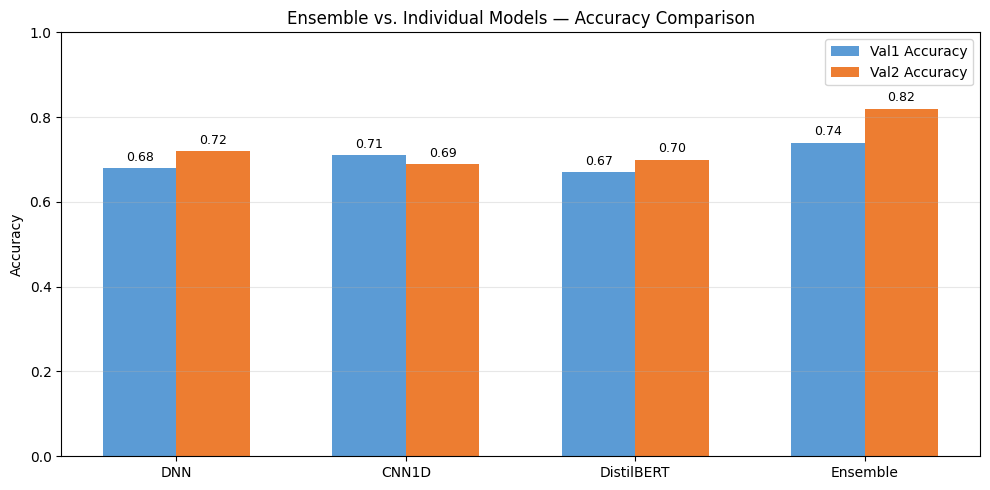

In [10]:
models = ['DNN', 'CNN1D', 'DistilBERT', 'Ensemble']
val1_acc = [dnn_es_acc, cnn_es_acc, bert_es_acc, se_es_acc]
val2_acc = [dnn_eval_acc, cnn_eval_acc, bert_eval_acc, se_eval_acc]

x = np.arange(len(models))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, val1_acc, width, label='Val1 Accuracy', color='#5B9BD5')
bars2 = ax.bar(x + width/2, val2_acc, width, label='Val2 Accuracy', color='#ED7D31')

ax.set_ylabel('Accuracy')
ax.set_title('Ensemble vs. Individual Models — Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Summary


In [11]:
results_df = pd.DataFrame(results)
results_df

probs_path = os.path.join(ROOT, 'saved_models', 'ensemble_notebook_probs.npz')

np.savez(
    probs_path,
    dnn_es=dnn_es,
    dnn_eval=dnn_eval,
    cnn_es=cnn_es,
    cnn_eval=cnn_eval,
    bert_es=bert_es,
    bert_eval=bert_eval,
    soft_equal_es=soft_equal_es,
    soft_equal_eval=soft_equal_eval,
    soft_bal_es=soft_bal_es,
    soft_bal_eval=soft_bal_eval,
    y_es=df_es['label_id'].values,
    y_eval=df_eval['label_id'].values,
)

print(f'Probabilidades guardadas em {probs_path}')

Probabilidades guardadas em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/ensemble_notebook_probs.npz
